<a href="https://colab.research.google.com/github/alfredqbit/grcshjepa/blob/main/GR_CS_HJEPA_Chapter4_Colab_Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GR-CS-HJEPA Chapter 4 Colab Driver Notebook

This notebook bootstraps a browser-only Colab workflow for the Chapter 4 experiments in the GR-CS-HJEPA dissertation proposal. It creates or updates an installable Python package under `src/`, writes unit tests under `tests/`, runs smoke experiments for Study 1, Study 2, and Study 3, and archives outputs to Google Drive when available.

**Important:** smoke-mode results are pipeline checks only. They are not dissertation findings and should not be reported as evidence for the proposal's hypotheses.

The source of truth should become a GitHub repository. Use this notebook to bootstrap and run the workflow, then commit `src/`, `tests/`, `configs/`, and `scripts/` to GitHub.


In [1]:
# ============================================================
# 1. Runtime setup: Colab, Drive, project directory, and options
# ============================================================
from __future__ import annotations

import os
import sys
import json
import shutil
import subprocess
from pathlib import Path
from datetime import datetime, timezone

IN_COLAB = "google.colab" in sys.modules

# Optional: set this to your GitHub repository URL after you create one.
# Example: REPO_URL = "https://github.com/YOUR_USER/grcshjepa.git"
REPO_URL = "https://github.com/alfredqbit/grcshjepa.git"

# If True, this notebook writes the starter package scaffold into PROJECT_DIR.
# Set to False after you have a real GitHub repo and no longer want the scaffold overwritten.
WRITE_STARTER_SCAFFOLD = True
OVERWRITE_EXISTING_FILES = True

PROJECT_NAME = "grcshjepa"
BASE_DIR = Path("/content") if IN_COLAB else Path.cwd()
PROJECT_DIR = BASE_DIR / PROJECT_NAME

MOUNT_DRIVE = True
DRIVE_ARTIFACT_DIR = Path("/content/drive/MyDrive/grcshjepa_artifacts") if IN_COLAB else PROJECT_DIR / "artifacts"

if IN_COLAB and MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("PROJECT_DIR:", PROJECT_DIR)
print("DRIVE_ARTIFACT_DIR:", DRIVE_ARTIFACT_DIR)
print("UTC:", datetime.now(timezone.utc).isoformat())


Mounted at /content/drive
IN_COLAB: True
PROJECT_DIR: /content/grcshjepa
DRIVE_ARTIFACT_DIR: /content/drive/MyDrive/grcshjepa_artifacts
UTC: 2026-07-26T15:48:26.363345+00:00


In [2]:
# ============================================================
# 2. Clone/pull GitHub repo if provided; otherwise create local scaffold folder
# ============================================================
def run(cmd, *, cwd=None, check=False, env=None):
    print("$", " ".join(str(c) for c in cmd))
    result = subprocess.run(cmd, cwd=cwd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, env=env)
    print(result.stdout[-5000:])
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with return code {result.returncode}: {cmd}")
    return result

if REPO_URL.strip():
    if PROJECT_DIR.exists() and (PROJECT_DIR / ".git").exists():
        run(["git", "pull"], cwd=PROJECT_DIR, check=False)
    elif PROJECT_DIR.exists() and any(PROJECT_DIR.iterdir()):
        print(f"PROJECT_DIR exists and is not empty: {PROJECT_DIR}")
        print("Using existing directory. Set REPO_URL='' or remove directory if this is not intended.")
    else:
        PROJECT_DIR.parent.mkdir(parents=True, exist_ok=True)
        run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    PROJECT_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_DIR)
print("Working directory:", Path.cwd())


$ git clone https://github.com/alfredqbit/grcshjepa.git /content/grcshjepa
Cloning into '/content/grcshjepa'...

Working directory: /content/grcshjepa


In [3]:
# ============================================================
# 3. Write the starter src/tests/configs/scripts scaffold
# ============================================================
PROJECT_FILES = {
  "README.md": "# GR-CS-HJEPA Chapter 4 Colab Experimental Driver\n\nThis repository scaffold supports the Chapter 4 experimental pipeline for the GR-CS-HJEPA dissertation proposal. It is intentionally a starter implementation: smoke-mode runs verify that data generation, H-JEPA pretraining, downstream heads, routing metrics, damage interventions, and statistical utilities execute end to end.\n\n## Main workflow\n\n```bash\npython -m pip install -e \".[dev]\"\npytest -q\npython scripts/run_study1_smoke.py --config configs/smoke.yaml\npython scripts/run_study2_smoke.py --config configs/smoke.yaml\npython scripts/run_study3_smoke.py --config configs/smoke.yaml\n```\n\n## Design rule\n\nThe notebook is only the driver. The source of truth is `src/`, `tests/`, `configs/`, and `scripts/`.\n",
  "configs/smoke.yaml": "project: GR-CS-HJEPA-Chapter4\nsmoke_mode: true\nseed: 0\noutput_dir: runs/smoke\n\nmaze_size_train: 8\nmaze_size_ood: 10\nmaze_obstacle_prob: 0.18\nsorting_length_train: 8\nsorting_length_ood: 10\ntrain_samples: 96\nval_samples: 32\ntest_samples: 32\n\nlatent_dim: 32\nprojection_dim: 12\nhorizon_set: [1, 2]\nbatch_size: 16\nepochs: 1\nlr: 0.002\nema_tau: 0.99\nlambda_ac: 0.03\n\nn_neurons: 48\nn_filters: 2\ninternal_steps: 4\ndt: 0.08\nnoise_std: 0.01\nsurrogate_eps: 0.7\n\ndownstream_label_fraction: 0.20\nhead_epochs: 1\nhead_lr: 0.002\n\nrouting_nodes: 28\nrouting_segments: 72\nrouting_terminals: 10\ndamage_levels: [0.05, 0.10]\n",
  "pyproject.toml": "[build-system]\nrequires = [\"setuptools>=61\", \"wheel\"]\nbuild-backend = \"setuptools.build_meta\"\n\n[project]\nname = \"grcshjepa\"\nversion = \"0.1.0\"\ndescription = \"GR-CS-HJEPA Chapter 4 experimental pipeline for Colab\"\nrequires-python = \">=3.10\"\ndependencies = [\n  \"numpy\",\n  \"pandas\",\n  \"scipy\",\n  \"matplotlib\",\n  \"torch\",\n  \"pyyaml\",\n  \"tqdm\"\n]\n\n[project.optional-dependencies]\ndev = [\n  \"pytest\",\n  \"pytest-cov\",\n  \"ruff\",\n  \"black\",\n  \"jupyter\",\n  \"ipykernel\"\n]\n\n[tool.setuptools.packages.find]\nwhere = [\"src\"]\n\n[tool.ruff]\nline-length = 100\n\n[tool.black]\nline-length = 100\n",
  "scripts/run_all_smoke.py": "from __future__ import annotations\n\nimport argparse\nfrom pathlib import Path\n\nimport pandas as pd\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.experiments.study1 import run_study1_smoke\nfrom grcshjepa.experiments.study2 import run_study2_smoke\nfrom grcshjepa.experiments.study3 import run_study3_smoke\nfrom grcshjepa.utils import archive_directory\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--config\", default=\"configs/smoke.yaml\")\n    parser.add_argument(\"--seed\", type=int, default=None)\n    parser.add_argument(\"--output-dir\", default=None)\n    parser.add_argument(\"--archive\", action=\"store_true\")\n    args = parser.parse_args()\n    cfg = ExperimentConfig.from_yaml(args.config)\n    if args.seed is not None:\n        cfg = cfg.with_updates(seed=args.seed)\n    if args.output_dir is not None:\n        cfg = cfg.with_updates(output_dir=args.output_dir)\n    Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)\n    frames = [run_study1_smoke(cfg), run_study2_smoke(cfg), run_study3_smoke(cfg)]\n    summary = pd.concat(frames, ignore_index=True, sort=False)\n    summary.to_csv(Path(cfg.output_dir) / \"all_smoke_summary.csv\", index=False)\n    print(summary.head(30).to_string(index=False))\n    if args.archive:\n        archive = archive_directory(cfg.output_dir, str(Path(cfg.output_dir).with_suffix(\".tar.gz\")))\n        print(f\"Archived: {archive}\")\n\n\nif __name__ == \"__main__\":\n    main()\n",
  "scripts/run_study1_smoke.py": "from __future__ import annotations\n\nimport argparse\nfrom dataclasses import asdict\nfrom pathlib import Path\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.experiments.study1 import run_study1_smoke\nfrom grcshjepa.utils import save_json\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--config\", default=\"configs/smoke.yaml\")\n    parser.add_argument(\"--seed\", type=int, default=None)\n    parser.add_argument(\"--output-dir\", default=None)\n    args = parser.parse_args()\n    cfg = ExperimentConfig.from_yaml(args.config)\n    if args.seed is not None:\n        cfg = cfg.with_updates(seed=args.seed)\n    if args.output_dir is not None:\n        cfg = cfg.with_updates(output_dir=args.output_dir)\n    Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)\n    save_json(asdict(cfg), Path(cfg.output_dir) / \"resolved_config_study1.json\")\n    df = run_study1_smoke(cfg)\n    print(df.to_string(index=False))\n\n\nif __name__ == \"__main__\":\n    main()\n",
  "scripts/run_study2_smoke.py": "from __future__ import annotations\n\nimport argparse\nfrom dataclasses import asdict\nfrom pathlib import Path\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.experiments.study2 import run_study2_smoke\nfrom grcshjepa.utils import save_json\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--config\", default=\"configs/smoke.yaml\")\n    parser.add_argument(\"--seed\", type=int, default=None)\n    parser.add_argument(\"--output-dir\", default=None)\n    args = parser.parse_args()\n    cfg = ExperimentConfig.from_yaml(args.config)\n    if args.seed is not None:\n        cfg = cfg.with_updates(seed=args.seed)\n    if args.output_dir is not None:\n        cfg = cfg.with_updates(output_dir=args.output_dir)\n    Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)\n    save_json(asdict(cfg), Path(cfg.output_dir) / \"resolved_config_study2.json\")\n    df = run_study2_smoke(cfg)\n    print(df.to_string(index=False))\n\n\nif __name__ == \"__main__\":\n    main()\n",
  "scripts/run_study3_smoke.py": "from __future__ import annotations\n\nimport argparse\nfrom dataclasses import asdict\nfrom pathlib import Path\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.experiments.study3 import run_study3_smoke\nfrom grcshjepa.utils import save_json\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--config\", default=\"configs/smoke.yaml\")\n    parser.add_argument(\"--seed\", type=int, default=None)\n    parser.add_argument(\"--output-dir\", default=None)\n    args = parser.parse_args()\n    cfg = ExperimentConfig.from_yaml(args.config)\n    if args.seed is not None:\n        cfg = cfg.with_updates(seed=args.seed)\n    if args.output_dir is not None:\n        cfg = cfg.with_updates(output_dir=args.output_dir)\n    Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)\n    save_json(asdict(cfg), Path(cfg.output_dir) / \"resolved_config_study3.json\")\n    df = run_study3_smoke(cfg)\n    print(df.head(20).to_string(index=False))\n    print(f\"Rows written: {len(df)}\")\n\n\nif __name__ == \"__main__\":\n    main()\n",
  "src/grcshjepa/__init__.py": "",
  "src/grcshjepa/config.py": "from __future__ import annotations\n\nfrom dataclasses import dataclass, fields, asdict\nfrom pathlib import Path\nfrom typing import Any, Tuple\n\nimport yaml\n\n\n@dataclass(frozen=True)\nclass ExperimentConfig:\n    \"\"\"Configuration for GR-CS-HJEPA Chapter 4 experiments.\"\"\"\n\n    project: str = \"GR-CS-HJEPA-Chapter4\"\n    smoke_mode: bool = True\n    seed: int = 0\n    device: str = \"auto\"\n    output_dir: str = \"runs/smoke\"\n\n    # Procedural data\n    maze_size_train: int = 8\n    maze_size_ood: int = 10\n    maze_obstacle_prob: float = 0.18\n    sorting_length_train: int = 8\n    sorting_length_ood: int = 10\n    train_samples: int = 96\n    val_samples: int = 32\n    test_samples: int = 32\n\n    # H-JEPA\n    latent_dim: int = 32\n    projection_dim: int = 12\n    horizon_set: Tuple[int, ...] = (1, 2)\n    batch_size: int = 16\n    epochs: int = 1\n    lr: float = 2e-3\n    ema_tau: float = 0.99\n    lambda_ac: float = 0.03\n    lambda_suff: float = 0.0\n    lambda_alias: float = 0.0\n    lambda_unc: float = 0.0\n\n    # Relaxed continuous-spiking predictor\n    n_neurons: int = 48\n    n_filters: int = 2\n    internal_steps: int = 4\n    dt: float = 0.08\n    noise_std: float = 0.01\n    surrogate_eps: float = 0.7\n\n    # Downstream heads\n    downstream_label_fraction: float = 0.20\n    head_epochs: int = 1\n    head_lr: float = 2e-3\n\n    # Routing toy model\n    routing_nodes: int = 28\n    routing_segments: int = 72\n    routing_terminals: int = 10\n    damage_levels: Tuple[float, ...] = (0.05, 0.10)\n\n    @classmethod\n    def from_yaml(cls, path: str | Path) -> \"ExperimentConfig\":\n        path = Path(path)\n        data = yaml.safe_load(path.read_text()) if path.exists() else {}\n        data = {} if data is None else dict(data)\n        valid = {f.name for f in fields(cls)}\n        unknown = sorted(set(data) - valid)\n        if unknown:\n            raise ValueError(f\"Unknown config keys in {path}: {unknown}\")\n        if \"horizon_set\" in data and isinstance(data[\"horizon_set\"], list):\n            data[\"horizon_set\"] = tuple(int(x) for x in data[\"horizon_set\"])\n        if \"damage_levels\" in data and isinstance(data[\"damage_levels\"], list):\n            data[\"damage_levels\"] = tuple(float(x) for x in data[\"damage_levels\"])\n        return cls(**data)\n\n    def with_updates(self, **kwargs: Any) -> \"ExperimentConfig\":\n        data = asdict(self)\n        data.update(kwargs)\n        return ExperimentConfig(**data)\n\n    def to_dict(self) -> dict[str, Any]:\n        return asdict(self)\n",
  "src/grcshjepa/data/__init__.py": "",
  "src/grcshjepa/data/datasets.py": "from __future__ import annotations\n\nfrom typing import Any\n\nimport numpy as np\nimport torch\nfrom torch.utils.data import Dataset\n\nfrom grcshjepa.tasks.maze import (\n    make_random_maze,\n    maze_observation,\n    next_action_from_path,\n    is_rare_critical_maze_state,\n)\nfrom grcshjepa.tasks.sorting import random_sorting_example, inversion_count\n\n\nclass MazeTrajectoryDataset(Dataset):\n    \"\"\"Procedural maze context-target pairs for JEPA-style latent prediction.\"\"\"\n\n    def __init__(self, n_samples: int, size: int, obstacle_prob: float, seed: int, horizon_set=(1, 2)):\n        self.n_samples = int(n_samples)\n        self.size = int(size)\n        self.obstacle_prob = float(obstacle_prob)\n        self.horizon_set = tuple(int(h) for h in horizon_set)\n        rng = np.random.default_rng(seed)\n        self.items: list[dict[str, Any]] = []\n        for _ in range(self.n_samples):\n            grid, start, goal, path = make_random_maze(size, obstacle_prob, rng)\n            idx = int(rng.integers(0, max(1, len(path) - 1)))\n            horizon = int(rng.choice(self.horizon_set))\n            future_idx = min(idx + horizon, len(path) - 1)\n            x = maze_observation(grid, path[idx], goal)\n            x_future = maze_observation(grid, path[future_idx], goal)\n            action = next_action_from_path(path, idx)\n            rare = is_rare_critical_maze_state(grid, path, idx)\n            self.items.append(\n                {\n                    \"x\": x,\n                    \"x_future\": x_future,\n                    \"horizon\": horizon,\n                    \"action\": action,\n                    \"rare\": rare,\n                    \"path_len\": len(path),\n                    \"grid\": grid,\n                    \"start\": start,\n                    \"goal\": goal,\n                    \"path\": path,\n                }\n            )\n\n    def __len__(self) -> int:\n        return len(self.items)\n\n    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:\n        item = self.items[idx]\n        return {\n            \"x\": torch.tensor(item[\"x\"], dtype=torch.float32),\n            \"x_future\": torch.tensor(item[\"x_future\"], dtype=torch.float32),\n            \"horizon\": torch.tensor(item[\"horizon\"], dtype=torch.long),\n            \"action\": torch.tensor(item[\"action\"], dtype=torch.long),\n            \"rare\": torch.tensor(float(item[\"rare\"]), dtype=torch.float32),\n            \"difficulty\": torch.tensor(float(item[\"path_len\"]), dtype=torch.float32),\n        }\n\n\nclass SortingTrajectoryDataset(Dataset):\n    \"\"\"Sorting context-target pairs along a bubble-sort trajectory.\"\"\"\n\n    def __init__(self, n_samples: int, length: int, seed: int, horizon_set=(1, 2)):\n        self.n_samples = int(n_samples)\n        self.length = int(length)\n        self.horizon_set = tuple(int(h) for h in horizon_set)\n        rng = np.random.default_rng(seed)\n        self.items: list[dict[str, Any]] = []\n        for _ in range(self.n_samples):\n            seq, trajectory = random_sorting_example(length, rng)\n            idx = int(rng.integers(0, max(1, len(trajectory))))\n            idx = min(idx, len(trajectory) - 1)\n            horizon = int(rng.choice(self.horizon_set))\n            future_idx = min(idx + horizon, len(trajectory) - 1)\n            x = trajectory[idx]\n            x_future = trajectory[future_idx]\n            y_sorted = np.sort(seq)\n            self.items.append(\n                {\n                    \"x\": x.astype(np.float32),\n                    \"x_future\": x_future.astype(np.float32),\n                    \"horizon\": horizon,\n                    \"y_sorted\": y_sorted.astype(np.float32),\n                    \"difficulty\": inversion_count(x),\n                }\n            )\n\n    def __len__(self) -> int:\n        return len(self.items)\n\n    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:\n        item = self.items[idx]\n        return {\n            \"x\": torch.tensor(item[\"x\"], dtype=torch.float32),\n            \"x_future\": torch.tensor(item[\"x_future\"], dtype=torch.float32),\n            \"horizon\": torch.tensor(item[\"horizon\"], dtype=torch.long),\n            \"y_sorted\": torch.tensor(item[\"y_sorted\"], dtype=torch.float32),\n            \"difficulty\": torch.tensor(float(item[\"difficulty\"]), dtype=torch.float32),\n        }\n",
  "src/grcshjepa/diagnostics.py": "from __future__ import annotations\n\nimport numpy as np\nimport torch\n\nfrom grcshjepa.losses import effective_rank_from_eigs\n\n\ndef covariance_diagnostics(y: torch.Tensor) -> dict[str, float]:\n    if y.ndim != 2:\n        raise ValueError(\"Expected [batch, dim] tensor.\")\n    centered = y - y.mean(dim=0)\n    cov = centered.T @ centered / max(1, y.shape[0] - 1)\n    eig = torch.linalg.eigvalsh(cov).clamp_min(0)\n    return {\n        \"cov_trace\": float(torch.trace(cov).detach().cpu()),\n        \"cov_min_eig\": float(eig.min().detach().cpu()) if eig.numel() else 0.0,\n        \"cov_max_eig\": float(eig.max().detach().cpu()) if eig.numel() else 0.0,\n        \"effective_rank\": effective_rank_from_eigs(eig.detach().cpu()),\n    }\n\n\ndef latent_aliasing_rate(z: torch.Tensor, labels: torch.Tensor, distance_quantile: float = 0.05) -> float:\n    \"\"\"Crude harmful-alias diagnostic: near latent pairs with different labels.\"\"\"\n    if z.shape[0] < 3:\n        return 0.0\n    z = torch.nn.functional.normalize(z.detach(), dim=-1)\n    d = torch.cdist(z, z)\n    mask = ~torch.eye(z.shape[0], dtype=torch.bool, device=z.device)\n    vals = d[mask]\n    threshold = torch.quantile(vals, distance_quantile)\n    near = (d <= threshold) & mask\n    diff = labels.view(-1, 1) != labels.view(1, -1)\n    denom = near.sum().item()\n    if denom == 0:\n        return 0.0\n    return float((near & diff).sum().item() / denom)\n\n\ndef timescale_autocorrelation_time(values: np.ndarray, max_lag: int = 20) -> float:\n    x = np.asarray(values, dtype=float)\n    if x.size < 3 or np.std(x) == 0:\n        return 0.0\n    x = x - x.mean()\n    denom = np.dot(x, x)\n    ac = []\n    for lag in range(1, min(max_lag, x.size - 1) + 1):\n        ac.append(float(np.dot(x[:-lag], x[lag:]) / denom))\n    positive = [v for v in ac if v > 0]\n    return float(1.0 + 2.0 * np.sum(positive))\n\n\ndef risk_coverage_curve(confidence: np.ndarray, correct: np.ndarray, steps: int = 10) -> list[dict[str, float]]:\n    confidence = np.asarray(confidence)\n    correct = np.asarray(correct).astype(float)\n    out = []\n    for q in np.linspace(0.0, 1.0, steps):\n        thresh = np.quantile(confidence, q)\n        keep = confidence >= thresh\n        out.append(\n            {\n                \"coverage\": float(keep.mean()),\n                \"risk\": float(1.0 - correct[keep].mean()) if keep.any() else float(\"nan\"),\n                \"threshold\": float(thresh),\n            }\n        )\n    return out\n",
  "src/grcshjepa/experiments/__init__.py": "from grcshjepa.experiments.study1 import run_study1_smoke\nfrom grcshjepa.experiments.study2 import run_study2_smoke\nfrom grcshjepa.experiments.study3 import run_study3_smoke\n\n__all__ = [\"run_study1_smoke\", \"run_study2_smoke\", \"run_study3_smoke\"]\n",
  "src/grcshjepa/experiments/study1.py": "from __future__ import annotations\n\nfrom pathlib import Path\n\nimport pandas as pd\nimport torch\nfrom torch.utils.data import DataLoader\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.data.datasets import MazeTrajectoryDataset, SortingTrajectoryDataset\nfrom grcshjepa.models.encoders import MazeEncoder, SortingEncoder\nfrom grcshjepa.models.hjepa import HJEPA\nfrom grcshjepa.models.predictors import MLPPredictor, RelaxedContinuousSpikingPredictor\nfrom grcshjepa.training.pretrain import train_jepa_epoch, evaluate_jepa\nfrom grcshjepa.utils import resolve_device, set_seed, write_manifest, environment_report\n\n\ndef _make_hjepa(cfg: ExperimentConfig, encoder, predictor_type: str):\n    max_horizon = max(cfg.horizon_set)\n    horizon_dim = 16\n    if predictor_type == \"spiking\":\n        predictor = RelaxedContinuousSpikingPredictor(\n            latent_dim=cfg.latent_dim,\n            horizon_dim=horizon_dim,\n            n_neurons=cfg.n_neurons,\n            n_filters=cfg.n_filters,\n            internal_steps=cfg.internal_steps,\n            dt=cfg.dt,\n            noise_std=cfg.noise_std,\n            surrogate_eps=cfg.surrogate_eps,\n        )\n    else:\n        predictor = MLPPredictor(latent_dim=cfg.latent_dim, horizon_dim=horizon_dim)\n    return HJEPA(\n        encoder=encoder,\n        latent_dim=cfg.latent_dim,\n        projection_dim=cfg.projection_dim,\n        max_horizon=max_horizon,\n        predictor=predictor,\n        horizon_dim=horizon_dim,\n    )\n\n\ndef run_study1_smoke(cfg: ExperimentConfig) -> pd.DataFrame:\n    \"\"\"Run Study 1 smoke: H-JEPA predictive pretraining on maze and sorting pairs.\"\"\"\n    set_seed(cfg.seed)\n    device = resolve_device(cfg.device)\n    outdir = Path(cfg.output_dir) / \"study1_smoke\"\n    outdir.mkdir(parents=True, exist_ok=True)\n\n    rows = []\n    for task in [\"maze\", \"sorting\"]:\n        if task == \"maze\":\n            train_ds = MazeTrajectoryDataset(cfg.train_samples, cfg.maze_size_train, cfg.maze_obstacle_prob, cfg.seed, cfg.horizon_set)\n            val_ds = MazeTrajectoryDataset(cfg.val_samples, cfg.maze_size_train, cfg.maze_obstacle_prob, cfg.seed + 101, cfg.horizon_set)\n            encoder = MazeEncoder(cfg.latent_dim)\n        else:\n            train_ds = SortingTrajectoryDataset(cfg.train_samples, cfg.sorting_length_train, cfg.seed + 2, cfg.horizon_set)\n            val_ds = SortingTrajectoryDataset(cfg.val_samples, cfg.sorting_length_train, cfg.seed + 202, cfg.horizon_set)\n            encoder = SortingEncoder(cfg.sorting_length_train, cfg.latent_dim)\n\n        for predictor_type in [\"mlp\", \"spiking\"]:\n            model = _make_hjepa(cfg, encoder if predictor_type == \"mlp\" else type(encoder)(*([cfg.latent_dim] if task == \"maze\" else [cfg.sorting_length_train, cfg.latent_dim])), predictor_type)\n            model.to(device)\n            opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)\n            train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)\n            val_loader = DataLoader(val_ds, batch_size=cfg.batch_size)\n            metrics = {}\n            for epoch in range(cfg.epochs):\n                train_metrics = train_jepa_epoch(model, train_loader, opt, device, lambda_ac=cfg.lambda_ac, ema_tau=cfg.ema_tau)\n                val_metrics = evaluate_jepa(model, val_loader, device)\n                metrics = {**train_metrics, **{f\"val_{k}\": v for k, v in val_metrics.items()}}\n            rows.append({\"study\": \"study1\", \"task\": task, \"predictor\": predictor_type, \"seed\": cfg.seed, **metrics})\n\n    df = pd.DataFrame(rows)\n    df.to_csv(outdir / f\"study1_seed{cfg.seed}.csv\", index=False)\n    write_manifest(outdir / f\"manifest_seed{cfg.seed}.json\", {\"study\": \"study1\", \"seed\": cfg.seed, \"rows\": len(df), \"environment\": environment_report()})\n    return df\n",
  "src/grcshjepa/experiments/study2.py": "from __future__ import annotations\n\nfrom pathlib import Path\n\nimport pandas as pd\nimport torch\nfrom torch.utils.data import DataLoader\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.data.datasets import MazeTrajectoryDataset, SortingTrajectoryDataset\nfrom grcshjepa.experiments.study1 import _make_hjepa\nfrom grcshjepa.models.encoders import MazeEncoder, SortingEncoder\nfrom grcshjepa.models.heads import MazeActionHead, SortingHead\nfrom grcshjepa.training.downstream import (\n    make_labeled_subset,\n    encode_dataset,\n    train_classification_head,\n    evaluate_classification_head,\n    train_regression_head,\n    evaluate_regression_head,\n)\nfrom grcshjepa.training.pretrain import train_jepa_epoch\nfrom grcshjepa.utils import resolve_device, set_seed, write_manifest, environment_report\n\n\ndef _pretrain_for_downstream(cfg: ExperimentConfig, task: str, device: torch.device):\n    if task == \"maze\":\n        train_ds = MazeTrajectoryDataset(cfg.train_samples, cfg.maze_size_train, cfg.maze_obstacle_prob, cfg.seed, cfg.horizon_set)\n        encoder = MazeEncoder(cfg.latent_dim)\n    else:\n        train_ds = SortingTrajectoryDataset(cfg.train_samples, cfg.sorting_length_train, cfg.seed + 2, cfg.horizon_set)\n        encoder = SortingEncoder(cfg.sorting_length_train, cfg.latent_dim)\n    model = _make_hjepa(cfg, encoder, \"spiking\").to(device)\n    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)\n    loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)\n    for _ in range(cfg.epochs):\n        train_jepa_epoch(model, loader, opt, device, lambda_ac=cfg.lambda_ac, ema_tau=cfg.ema_tau)\n    return model\n\n\ndef run_study2_smoke(cfg: ExperimentConfig) -> pd.DataFrame:\n    \"\"\"Run Study 2 smoke: frozen encoder plus small downstream heads.\"\"\"\n    set_seed(cfg.seed)\n    device = resolve_device(cfg.device)\n    outdir = Path(cfg.output_dir) / \"study2_smoke\"\n    outdir.mkdir(parents=True, exist_ok=True)\n    rows = []\n\n    # Maze action head\n    maze_model = _pretrain_for_downstream(cfg, \"maze\", device)\n    train_maze = MazeTrajectoryDataset(cfg.train_samples, cfg.maze_size_train, cfg.maze_obstacle_prob, cfg.seed + 10, cfg.horizon_set)\n    test_maze = MazeTrajectoryDataset(cfg.test_samples, cfg.maze_size_train, cfg.maze_obstacle_prob, cfg.seed + 11, cfg.horizon_set)\n    labeled_maze = make_labeled_subset(train_maze, cfg.downstream_label_fraction, cfg.seed)\n    z_train, y_train = encode_dataset(maze_model.encoder, DataLoader(labeled_maze, batch_size=cfg.batch_size), device, \"action\")\n    z_test, y_test = encode_dataset(maze_model.encoder, DataLoader(test_maze, batch_size=cfg.batch_size), device, \"action\")\n    head = MazeActionHead(cfg.latent_dim)\n    train_m = train_classification_head(head, z_train, y_train, epochs=cfg.head_epochs, lr=cfg.head_lr)\n    test_m = evaluate_classification_head(head, z_test, y_test)\n    rows.append({\"study\": \"study2\", \"task\": \"maze_action\", \"seed\": cfg.seed, **train_m, **test_m})\n\n    # Sorting regression head\n    sort_model = _pretrain_for_downstream(cfg, \"sorting\", device)\n    train_sort = SortingTrajectoryDataset(cfg.train_samples, cfg.sorting_length_train, cfg.seed + 20, cfg.horizon_set)\n    test_sort = SortingTrajectoryDataset(cfg.test_samples, cfg.sorting_length_train, cfg.seed + 21, cfg.horizon_set)\n    labeled_sort = make_labeled_subset(train_sort, cfg.downstream_label_fraction, cfg.seed)\n    z_train, y_train = encode_dataset(sort_model.encoder, DataLoader(labeled_sort, batch_size=cfg.batch_size), device, \"y_sorted\")\n    z_test, y_test = encode_dataset(sort_model.encoder, DataLoader(test_sort, batch_size=cfg.batch_size), device, \"y_sorted\")\n    head = SortingHead(cfg.latent_dim, cfg.sorting_length_train)\n    train_m = train_regression_head(head, z_train, y_train, epochs=cfg.head_epochs, lr=cfg.head_lr)\n    test_m = evaluate_regression_head(head, z_test, y_test)\n    rows.append({\"study\": \"study2\", \"task\": \"sorting_head\", \"seed\": cfg.seed, **train_m, **test_m})\n\n    df = pd.DataFrame(rows)\n    df.to_csv(outdir / f\"study2_seed{cfg.seed}.csv\", index=False)\n    write_manifest(outdir / f\"manifest_seed{cfg.seed}.json\", {\"study\": \"study2\", \"seed\": cfg.seed, \"rows\": len(df), \"environment\": environment_report()})\n    return df\n",
  "src/grcshjepa/experiments/study3.py": "from __future__ import annotations\n\nfrom pathlib import Path\n\nimport pandas as pd\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.routing.graph import make_toy_routing_graph\nfrom grcshjepa.routing.surface import routing_surface\nfrom grcshjepa.routing.damage import apply_damage\nfrom grcshjepa.utils import set_seed, write_manifest, environment_report\n\n\ndef run_study3_smoke(cfg: ExperimentConfig) -> pd.DataFrame:\n    \"\"\"Run Study 3 smoke: routing-surface metrics and cable-damage interventions.\"\"\"\n    set_seed(cfg.seed)\n    outdir = Path(cfg.output_dir) / \"study3_smoke\"\n    outdir.mkdir(parents=True, exist_ok=True)\n    rows = []\n    variants = [\"sparsity\", \"euclidean_length\", \"tube_only\", \"full_surface\"]\n    damage_types = [\"uniform\", \"spatial\", \"load_targeted\"]\n    for variant in variants:\n        graph = make_toy_routing_graph(cfg.routing_nodes, cfg.routing_segments, cfg.seed, variant)\n        base = routing_surface(graph)\n        rows.append({\"study\": \"study3\", \"variant\": variant, \"damage_type\": \"none\", \"damage_level\": 0.0, **base})\n        for dtype in damage_types:\n            for level in cfg.damage_levels:\n                damaged = apply_damage(graph, dtype, level, seed=cfg.seed + int(level * 1000) + len(dtype))\n                metrics = routing_surface(damaged)\n                metrics[\"surface_degradation\"] = metrics[\"normalized_surface\"] - base[\"normalized_surface\"]\n                metrics[\"traffic_degradation\"] = base[\"delivered_traffic\"] - metrics[\"delivered_traffic\"]\n                rows.append({\"study\": \"study3\", \"variant\": variant, \"damage_type\": dtype, \"damage_level\": level, **metrics})\n    df = pd.DataFrame(rows)\n    df.to_csv(outdir / f\"study3_seed{cfg.seed}.csv\", index=False)\n    write_manifest(outdir / f\"manifest_seed{cfg.seed}.json\", {\"study\": \"study3\", \"seed\": cfg.seed, \"rows\": len(df), \"environment\": environment_report()})\n    return df\n",
  "src/grcshjepa/losses.py": "from __future__ import annotations\n\nfrom typing import Dict, Tuple\n\nimport torch\nimport torch.nn.functional as F\n\n\ndef normalize_latent(z: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:\n    return z / (z.norm(dim=-1, keepdim=True) + eps)\n\n\ndef normalized_prediction_loss(z_hat: torch.Tensor, z_tgt: torch.Tensor) -> torch.Tensor:\n    \"\"\"Cosine-style squared error on normalized latent states.\"\"\"\n    z_hat_n = normalize_latent(z_hat)\n    z_tgt_n = normalize_latent(z_tgt.detach())\n    return F.mse_loss(z_hat_n, z_tgt_n)\n\n\ndef effective_rank_from_eigs(eigs: torch.Tensor, eps: float = 1e-12) -> float:\n    vals = torch.as_tensor(eigs, dtype=torch.float64).clamp_min(0)\n    total = vals.sum()\n    if float(total) <= eps:\n        return 0.0\n    p = vals / total\n    entropy = -(p * (p + eps).log()).sum()\n    return float(torch.exp(entropy))\n\n\ndef anti_collapse_loss(y: torch.Tensor, eps: float = 1e-6) -> Tuple[torch.Tensor, Dict[str, float]]:\n    \"\"\"First- and second-moment anti-collapse loss.\n\n    The loss penalizes nonzero batch mean and covariance away from identity. A constant embedding\n    has covariance near zero and therefore incurs a dimension-scale penalty.\n    \"\"\"\n    if y.ndim != 2:\n        raise ValueError(f\"Expected y with shape [batch, dim], got {tuple(y.shape)}\")\n    batch_size, dim = y.shape\n    mean = y.mean(dim=0)\n    centered = y - mean\n    if batch_size <= 1:\n        cov = torch.zeros(dim, dim, device=y.device, dtype=y.dtype)\n    else:\n        cov = centered.T @ centered / (batch_size - 1)\n    eye = torch.eye(dim, device=y.device, dtype=y.dtype)\n    loss = mean.pow(2).sum() + (cov - eye).pow(2).sum()\n    with torch.no_grad():\n        eig = torch.linalg.eigvalsh(cov).clamp_min(0)\n        stats = {\n            \"ac_mean_norm\": float(mean.norm().detach().cpu()),\n            \"ac_cov_trace\": float(torch.trace(cov).detach().cpu()),\n            \"ac_cov_min_eig\": float(eig.min().detach().cpu()) if eig.numel() else 0.0,\n            \"ac_cov_max_eig\": float(eig.max().detach().cpu()) if eig.numel() else 0.0,\n            \"ac_effective_rank\": effective_rank_from_eigs(eig.detach().cpu()),\n        }\n    return loss, stats\n",
  "src/grcshjepa/models/__init__.py": "",
  "src/grcshjepa/models/encoders.py": "from __future__ import annotations\n\nimport torch\nimport torch.nn as nn\n\n\nclass MazeEncoder(nn.Module):\n    \"\"\"Small CNN encoder for smoke-mode maze observations.\"\"\"\n\n    def __init__(self, latent_dim: int = 32):\n        super().__init__()\n        self.net = nn.Sequential(\n            nn.Conv2d(4, 16, kernel_size=3, padding=1),\n            nn.GELU(),\n            nn.Conv2d(16, 24, kernel_size=3, padding=1),\n            nn.GELU(),\n            nn.AdaptiveAvgPool2d((1, 1)),\n            nn.Flatten(),\n            nn.Linear(24, latent_dim),\n        )\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return self.net(x)\n\n\nclass SortingEncoder(nn.Module):\n    \"\"\"Small MLP encoder for sequence states.\"\"\"\n\n    def __init__(self, length: int, latent_dim: int = 32):\n        super().__init__()\n        self.length = int(length)\n        self.net = nn.Sequential(\n            nn.Linear(length, 64),\n            nn.GELU(),\n            nn.Linear(64, latent_dim),\n        )\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return self.net(x)\n",
  "src/grcshjepa/models/heads.py": "from __future__ import annotations\n\nimport torch\nimport torch.nn as nn\n\n\nclass MazeActionHead(nn.Module):\n    def __init__(self, latent_dim: int = 32, n_actions: int = 4):\n        super().__init__()\n        self.net = nn.Sequential(nn.Linear(latent_dim, 48), nn.GELU(), nn.Linear(48, n_actions))\n\n    def forward(self, z: torch.Tensor) -> torch.Tensor:\n        return self.net(z)\n\n\nclass SortingHead(nn.Module):\n    def __init__(self, latent_dim: int = 32, length: int = 8):\n        super().__init__()\n        self.net = nn.Sequential(nn.Linear(latent_dim, 64), nn.GELU(), nn.Linear(64, length))\n\n    def forward(self, z: torch.Tensor) -> torch.Tensor:\n        return self.net(z)\n\n\nclass ValueHead(nn.Module):\n    def __init__(self, latent_dim: int = 32):\n        super().__init__()\n        self.net = nn.Sequential(nn.Linear(latent_dim, 48), nn.GELU(), nn.Linear(48, 1))\n\n    def forward(self, z: torch.Tensor) -> torch.Tensor:\n        return self.net(z).squeeze(-1)\n\n\nclass VerifierPredicateHead(nn.Module):\n    def __init__(self, latent_dim: int = 32, n_predicates: int = 4):\n        super().__init__()\n        self.net = nn.Sequential(nn.Linear(latent_dim, 48), nn.GELU(), nn.Linear(48, n_predicates))\n\n    def forward(self, z: torch.Tensor) -> torch.Tensor:\n        return self.net(z)\n",
  "src/grcshjepa/models/hjepa.py": "from __future__ import annotations\n\nimport copy\nfrom typing import Dict\n\nimport torch\nimport torch.nn as nn\n\nfrom grcshjepa.models.predictors import HorizonEmbedding\n\n\nclass HJEPA(nn.Module):\n    \"\"\"H-JEPA wrapper with online encoder, EMA target encoder, predictor, and projector.\"\"\"\n\n    def __init__(\n        self,\n        encoder: nn.Module,\n        latent_dim: int,\n        projection_dim: int,\n        max_horizon: int,\n        predictor: nn.Module,\n        horizon_dim: int = 16,\n    ):\n        super().__init__()\n        self.encoder = encoder\n        self.target_encoder = copy.deepcopy(encoder)\n        for p in self.target_encoder.parameters():\n            p.requires_grad = False\n        self.horizon = HorizonEmbedding(max_horizon=max_horizon, dim=horizon_dim)\n        self.predictor = predictor\n        self.projector = nn.Sequential(\n            nn.Linear(latent_dim, 64),\n            nn.GELU(),\n            nn.Linear(64, projection_dim),\n        )\n\n    @torch.no_grad()\n    def update_target(self, tau: float = 0.99) -> None:\n        if not 0.0 <= tau <= 1.0:\n            raise ValueError(f\"EMA tau must be in [0,1], got {tau}\")\n        for target, online in zip(self.target_encoder.parameters(), self.encoder.parameters()):\n            target.data.mul_(tau).add_(online.data, alpha=1.0 - tau)\n\n    def encode(self, x: torch.Tensor) -> torch.Tensor:\n        return self.encoder(x)\n\n    @torch.no_grad()\n    def encode_target(self, x_future: torch.Tensor) -> torch.Tensor:\n        # stop-gradient target embedding\n        return self.target_encoder(x_future).detach()\n\n    def forward(self, x: torch.Tensor, x_future: torch.Tensor, horizon: torch.Tensor) -> Dict[str, torch.Tensor]:\n        z = self.encoder(x)\n        h = self.horizon(horizon)\n        z_hat = self.predictor(z, h)\n        z_tgt = self.encode_target(x_future)\n        y_proj = self.projector(z)\n        return {\"z\": z, \"z_hat\": z_hat, \"z_tgt\": z_tgt, \"y_proj\": y_proj}\n",
  "src/grcshjepa/models/predictors.py": "from __future__ import annotations\n\nimport torch\nimport torch.nn as nn\n\n\nclass HorizonEmbedding(nn.Module):\n    def __init__(self, max_horizon: int, dim: int):\n        super().__init__()\n        self.max_horizon = int(max_horizon)\n        self.emb = nn.Embedding(self.max_horizon + 1, dim)\n\n    def forward(self, horizon: torch.Tensor) -> torch.Tensor:\n        horizon = horizon.clamp(0, self.max_horizon)\n        return self.emb(horizon)\n\n\nclass MLPPredictor(nn.Module):\n    \"\"\"Simple latent predictor baseline.\"\"\"\n\n    def __init__(self, latent_dim: int = 32, horizon_dim: int = 16):\n        super().__init__()\n        self.net = nn.Sequential(\n            nn.Linear(latent_dim + horizon_dim, 96),\n            nn.GELU(),\n            nn.Linear(96, latent_dim),\n        )\n\n    def forward(self, z: torch.Tensor, h: torch.Tensor) -> torch.Tensor:\n        return self.net(torch.cat([z, h], dim=-1))\n\n\nclass RelaxedContinuousSpikingPredictor(nn.Module):\n    \"\"\"Tiny relaxed continuous-spiking predictor used as an executable stand-in.\n\n    This is not a full neuromorphic simulator. It implements the proposal's training-time\n    relaxation pattern: smooth surrogate spikes, finite filter state, Euler-style internal updates,\n    and a latent projection after internal computation.\n    \"\"\"\n\n    def __init__(\n        self,\n        latent_dim: int = 32,\n        horizon_dim: int = 16,\n        n_neurons: int = 48,\n        n_filters: int = 2,\n        internal_steps: int = 4,\n        dt: float = 0.08,\n        noise_std: float = 0.01,\n        surrogate_eps: float = 0.7,\n    ):\n        super().__init__()\n        self.latent_dim = int(latent_dim)\n        self.horizon_dim = int(horizon_dim)\n        self.n_neurons = int(n_neurons)\n        self.n_filters = int(n_filters)\n        self.internal_steps = int(internal_steps)\n        self.dt = float(dt)\n        self.noise_std = float(noise_std)\n        self.surrogate_eps = float(surrogate_eps)\n\n        self.inp = nn.Linear(latent_dim + horizon_dim, n_neurons)\n        self.recurrent = nn.Linear(n_neurons, n_neurons, bias=False)\n        self.filter_mix = nn.Linear(n_neurons * n_filters, n_neurons)\n        self.out = nn.Linear(n_neurons * (1 + n_filters), latent_dim)\n        self.threshold = nn.Parameter(torch.zeros(n_neurons))\n        self.tau_m_log = nn.Parameter(torch.zeros(n_neurons))\n        self.tau_f_log = nn.Parameter(torch.zeros(n_filters))\n\n    def forward(self, z: torch.Tensor, h: torch.Tensor) -> torch.Tensor:\n        batch = z.shape[0]\n        context = self.inp(torch.cat([z, h], dim=-1))\n        u = torch.tanh(context)\n        filters = torch.zeros(batch, self.n_neurons, self.n_filters, device=z.device, dtype=z.dtype)\n\n        tau_m = torch.nn.functional.softplus(self.tau_m_log) + 0.2\n        tau_f = torch.nn.functional.softplus(self.tau_f_log) + 0.2\n\n        for _ in range(self.internal_steps):\n            spikes = torch.sigmoid((u - self.threshold) / self.surrogate_eps)\n            rec = self.recurrent(spikes)\n            filt_drive = self.filter_mix(filters.reshape(batch, -1))\n            drift = -u / tau_m + rec + filt_drive + context\n            if self.training and self.noise_std > 0:\n                noise = self.noise_std * (self.dt**0.5) * torch.randn_like(u)\n            else:\n                noise = 0.0\n            u = u + self.dt * drift + noise\n            filters = filters + self.dt * (-filters / tau_f.view(1, 1, -1) + spikes.unsqueeze(-1))\n\n        state = torch.cat([u, filters.reshape(batch, -1)], dim=-1)\n        return self.out(state)\n",
  "src/grcshjepa/routing/__init__.py": "",
  "src/grcshjepa/routing/damage.py": "from __future__ import annotations\n\nimport numpy as np\n\nfrom grcshjepa.routing.graph import RoutingGraphToy\n\n\ndef apply_damage(graph: RoutingGraphToy, damage_type: str, level: float, seed: int) -> RoutingGraphToy:\n    rng = np.random.default_rng(seed)\n    g = graph.copy()\n    n = len(g.segments)\n    k = max(1, int(round(level * n)))\n\n    if damage_type == \"uniform\":\n        idx = rng.choice(n, size=k, replace=False)\n    elif damage_type == \"spatial\":\n        center = rng.random(3)\n        mids = (g.positions[g.segments[:, 0]] + g.positions[g.segments[:, 1]]) / 2\n        dist = np.linalg.norm(mids - center, axis=1)\n        idx = np.argsort(dist)[:k]\n    elif damage_type == \"load_targeted\":\n        idx = np.argsort(g.loads * g.gates)[-k:]\n    else:\n        raise ValueError(f\"Unknown damage_type: {damage_type}\")\n\n    g.gates[idx] = 0.0\n    g.loads[idx] = 0.0\n    g.radii[idx] = 0.0\n    return g\n",
  "src/grcshjepa/routing/graph.py": "from __future__ import annotations\n\nfrom dataclasses import dataclass\n\nimport numpy as np\n\n\n@dataclass\nclass RoutingGraphToy:\n    positions: np.ndarray\n    segments: np.ndarray\n    gates: np.ndarray\n    loads: np.ndarray\n    radii: np.ndarray\n    variant: str\n\n    def copy(self) -> \"RoutingGraphToy\":\n        return RoutingGraphToy(\n            positions=self.positions.copy(),\n            segments=self.segments.copy(),\n            gates=self.gates.copy(),\n            loads=self.loads.copy(),\n            radii=self.radii.copy(),\n            variant=self.variant,\n        )\n\n\ndef make_toy_routing_graph(\n    n_nodes: int,\n    n_segments: int,\n    seed: int,\n    variant: str = \"full_surface\",\n) -> RoutingGraphToy:\n    rng = np.random.default_rng(seed)\n    positions = rng.random((n_nodes, 3))\n    segments = set()\n    # connect local nearest-ish random pairs\n    while len(segments) < n_segments:\n        i, j = rng.choice(n_nodes, size=2, replace=False)\n        a, b = (int(i), int(j)) if i < j else (int(j), int(i))\n        segments.add((a, b))\n    seg = np.array(sorted(segments), dtype=np.int64)\n    lengths = np.linalg.norm(positions[seg[:, 0]] - positions[seg[:, 1]], axis=1)\n    base_loads = rng.gamma(shape=2.0, scale=1.0, size=len(seg))\n\n    if variant == \"sparsity\":\n        gates = rng.beta(2.0, 4.0, size=len(seg))\n        loads = base_loads * gates\n    elif variant == \"euclidean_length\":\n        gates = np.exp(-2.0 * lengths)\n        loads = base_loads * gates\n    elif variant == \"tube_only\":\n        gates = rng.beta(3.0, 2.0, size=len(seg))\n        loads = base_loads * gates\n    else:  # full_surface bundles more load into shared segments\n        centrality = 1.0 / (0.2 + np.linalg.norm((positions[seg[:, 0]] + positions[seg[:, 1]]) / 2 - 0.5, axis=1))\n        gates = 1.0 / (1.0 + np.exp(-0.8 * (centrality - np.median(centrality))))\n        loads = (base_loads + centrality) * gates\n\n    radii = 0.015 + 0.025 * np.sqrt(np.maximum(loads, 0.0))\n    return RoutingGraphToy(positions=positions, segments=seg, gates=gates, loads=loads, radii=radii, variant=variant)\n",
  "src/grcshjepa/routing/surface.py": "from __future__ import annotations\n\nimport numpy as np\n\nfrom grcshjepa.routing.graph import RoutingGraphToy\n\n\ndef gini(x: np.ndarray) -> float:\n    x = np.asarray(x, dtype=float)\n    if x.size == 0 or np.allclose(x, 0):\n        return 0.0\n    x = np.sort(np.maximum(x, 0))\n    n = x.size\n    return float((2 * np.arange(1, n + 1) @ x) / (n * x.sum()) - (n + 1) / n)\n\n\ndef routing_lengths(graph: RoutingGraphToy) -> np.ndarray:\n    p = graph.positions\n    s = graph.segments\n    return np.linalg.norm(p[s[:, 0]] - p[s[:, 1]], axis=1)\n\n\ndef gate_entropy(graph: RoutingGraphToy, eps: float = 1e-8) -> float:\n    g = np.clip(graph.gates, eps, 1 - eps)\n    return float(np.mean(-(g * np.log(g) + (1 - g) * np.log(1 - g))))\n\n\ndef routing_surface(graph: RoutingGraphToy) -> dict[str, float]:\n    lengths = routing_lengths(graph)\n    active = graph.gates > 0.25\n    tube_area = 2.0 * np.pi * graph.radii * lengths * graph.gates\n    # crude junction correction: high-load graph nodes add local patch area\n    node_load = np.zeros(len(graph.positions))\n    for (i, j), load, gate in zip(graph.segments, graph.loads, graph.gates):\n        node_load[i] += load * gate\n        node_load[j] += load * gate\n    junction_area = 0.02 * np.sum(np.sqrt(np.maximum(node_load, 0.0)))\n    total_surface = float(np.sum(tube_area) + junction_area)\n    delivered = float(np.sum(np.abs(graph.loads) * graph.gates))\n    return {\n        \"variant\": graph.variant,\n        \"segments\": float(len(graph.segments)),\n        \"active_segments\": float(np.sum(active)),\n        \"total_length\": float(np.sum(lengths * graph.gates)),\n        \"tube_area\": float(np.sum(tube_area)),\n        \"junction_area\": float(junction_area),\n        \"surface\": total_surface,\n        \"delivered_traffic\": delivered,\n        \"normalized_surface\": float(total_surface / (delivered + 1e-8)),\n        \"gate_entropy\": gate_entropy(graph),\n        \"load_gini\": gini(graph.loads * graph.gates),\n    }\n",
  "src/grcshjepa/stats/__init__.py": "",
  "src/grcshjepa/stats/decision.py": "from __future__ import annotations\n\nimport numpy as np\n\n\ndef bootstrap_ci(values, alpha: float = 0.05, n_boot: int = 2000, seed: int = 0) -> tuple[float, float]:\n    values = np.asarray(values, dtype=float)\n    rng = np.random.default_rng(seed)\n    if values.size == 0:\n        return (float(\"nan\"), float(\"nan\"))\n    boots = [np.mean(rng.choice(values, size=values.size, replace=True)) for _ in range(n_boot)]\n    return (float(np.quantile(boots, alpha / 2)), float(np.quantile(boots, 1 - alpha / 2)))\n\n\ndef paired_noninferiority(candidate, reference, margin: float, alpha: float = 0.05, seed: int = 0) -> dict:\n    diff = np.asarray(candidate, dtype=float) - np.asarray(reference, dtype=float)\n    lo, hi = bootstrap_ci(diff, alpha=2 * alpha, seed=seed)  # one-sided alpha as two-sided 2 alpha\n    return {\n        \"mean_diff\": float(np.mean(diff)),\n        \"lower_bound\": lo,\n        \"upper_bound\": hi,\n        \"margin\": float(margin),\n        \"noninferior\": bool(lo > -margin),\n    }\n\n\ndef equivalence_interval(candidate, reference, margin: float, alpha: float = 0.05, seed: int = 0) -> dict:\n    diff = np.asarray(candidate, dtype=float) - np.asarray(reference, dtype=float)\n    lo, hi = bootstrap_ci(diff, alpha=2 * alpha, seed=seed)\n    return {\n        \"mean_diff\": float(np.mean(diff)),\n        \"lower_bound\": lo,\n        \"upper_bound\": hi,\n        \"margin\": float(margin),\n        \"equivalent\": bool(lo > -margin and hi < margin),\n    }\n\n\ndef classify_interval(lo: float, hi: float, support_region: tuple[float, float], null_region: tuple[float, float]) -> str:\n    s_lo, s_hi = support_region\n    n_lo, n_hi = null_region\n    if lo >= s_lo and hi <= s_hi:\n        return \"supported\"\n    if lo >= n_lo and hi <= n_hi:\n        return \"equivalent_to_null\"\n    if hi < s_lo or lo > s_hi:\n        return \"contradicted_or_too_small\"\n    return \"inconclusive\"\n\n\ndef damage_degradation(baseline, damaged) -> np.ndarray:\n    return np.asarray(baseline, dtype=float) - np.asarray(damaged, dtype=float)\n",
  "src/grcshjepa/tasks/__init__.py": "",
  "src/grcshjepa/tasks/maze.py": "from __future__ import annotations\n\nfrom collections import deque\nfrom typing import List, Optional, Tuple\n\nimport numpy as np\n\nCell = Tuple[int, int]\nPath = List[Cell]\nDIRS: list[Cell] = [(-1, 0), (1, 0), (0, -1), (0, 1)]\nDIR_TO_ID = {d: i for i, d in enumerate(DIRS)}\n\n\ndef bfs_shortest_path(grid: np.ndarray, start: Cell, goal: Cell) -> Optional[Path]:\n    \"\"\"Return a shortest path on a binary obstacle grid, or None if unreachable.\n\n    A value of 1 means wall; 0 means free.\n    \"\"\"\n    rows, cols = grid.shape\n    queue: deque[Cell] = deque([start])\n    parent: dict[Cell, Cell | None] = {start: None}\n\n    while queue:\n        r, c = queue.popleft()\n        if (r, c) == goal:\n            path: Path = []\n            cur: Cell | None = goal\n            while cur is not None:\n                path.append(cur)\n                cur = parent[cur]\n            return list(reversed(path))\n\n        for dr, dc in DIRS:\n            nr, nc = r + dr, c + dc\n            nxt = (nr, nc)\n            if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == 0 and nxt not in parent:\n                parent[nxt] = (r, c)\n                queue.append(nxt)\n    return None\n\n\ndef make_random_maze(\n    size: int,\n    obstacle_prob: float,\n    rng: np.random.Generator,\n    max_tries: int = 200,\n) -> tuple[np.ndarray, Cell, Cell, Path]:\n    \"\"\"Generate a reachable random maze with a nontrivial shortest path.\"\"\"\n    for _ in range(max_tries):\n        grid = (rng.random((size, size)) < obstacle_prob).astype(np.int64)\n        start = (int(rng.integers(0, size)), int(rng.integers(0, size)))\n        goal = (int(rng.integers(0, size)), int(rng.integers(0, size)))\n        if start == goal:\n            continue\n        grid[start] = 0\n        grid[goal] = 0\n        path = bfs_shortest_path(grid, start, goal)\n        if path is not None and len(path) >= max(4, size // 2):\n            return grid, start, goal, path\n\n    grid = np.zeros((size, size), dtype=np.int64)\n    start, goal = (0, 0), (size - 1, size - 1)\n    path = bfs_shortest_path(grid, start, goal)\n    if path is None:\n        raise RuntimeError(\"Empty fallback grid should be reachable.\")\n    return grid, start, goal, path\n\n\ndef maze_observation(grid: np.ndarray, pos: Cell, goal: Cell) -> np.ndarray:\n    \"\"\"Four-channel observation: walls, position, goal, normalized goal-distance field.\"\"\"\n    rows, cols = grid.shape\n    obs = np.zeros((4, rows, cols), dtype=np.float32)\n    obs[0] = grid.astype(np.float32)\n    obs[1, pos[0], pos[1]] = 1.0\n    obs[2, goal[0], goal[1]] = 1.0\n    rr, cc = np.meshgrid(np.arange(rows), np.arange(cols), indexing=\"ij\")\n    dist = np.abs(rr - goal[0]) + np.abs(cc - goal[1])\n    obs[3] = dist.astype(np.float32) / max(1.0, float(dist.max()))\n    return obs\n\n\ndef path_mask(size: int, path: Path) -> np.ndarray:\n    mask = np.zeros((size, size), dtype=np.float32)\n    for r, c in path:\n        mask[r, c] = 1.0\n    return mask\n\n\ndef next_action_from_path(path: Path, idx: int) -> int:\n    if idx >= len(path) - 1:\n        return 0\n    r, c = path[idx]\n    nr, nc = path[idx + 1]\n    return DIR_TO_ID[(nr - r, nc - c)]\n\n\ndef verify_maze_path(grid: np.ndarray, start: Cell, goal: Cell, path: Path) -> dict:\n    \"\"\"Verify that a path starts/ends correctly, uses adjacent moves, and avoids walls.\"\"\"\n    if not path:\n        return {\"valid\": False, \"reason\": \"empty_path\"}\n    if path[0] != start:\n        return {\"valid\": False, \"reason\": \"wrong_start\"}\n    if path[-1] != goal:\n        return {\"valid\": False, \"reason\": \"wrong_goal\"}\n\n    rows, cols = grid.shape\n    for idx, (r, c) in enumerate(path):\n        if not (0 <= r < rows and 0 <= c < cols):\n            return {\"valid\": False, \"reason\": f\"out_of_bounds_{idx}\"}\n        if grid[r, c] != 0:\n            return {\"valid\": False, \"reason\": f\"wall_{idx}\"}\n    for idx, ((r1, c1), (r2, c2)) in enumerate(zip(path, path[1:])):\n        if abs(r1 - r2) + abs(c1 - c2) != 1:\n            return {\"valid\": False, \"reason\": f\"non_adjacent_{idx}\"}\n    return {\"valid\": True, \"reason\": \"valid\", \"length\": len(path)}\n\n\ndef is_rare_critical_maze_state(grid: np.ndarray, path: Path, idx: int) -> bool:\n    \"\"\"Simple rare-critical flag for chokepoints, turns, and low-branching path states.\"\"\"\n    r, c = path[idx]\n    free_neighbors = 0\n    for dr, dc in DIRS:\n        nr, nc = r + dr, c + dc\n        if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1] and grid[nr, nc] == 0:\n            free_neighbors += 1\n    turn = False\n    if 0 < idx < len(path) - 1:\n        prev = np.array(path[idx]) - np.array(path[idx - 1])\n        nxt = np.array(path[idx + 1]) - np.array(path[idx])\n        turn = not np.array_equal(prev, nxt)\n    return bool(free_neighbors <= 2 or turn)\n",
  "src/grcshjepa/tasks/sorting.py": "from __future__ import annotations\n\nfrom typing import List, Tuple\n\nimport numpy as np\n\n\ndef inversion_count(seq: np.ndarray) -> int:\n    seq = np.asarray(seq)\n    count = 0\n    for i in range(len(seq)):\n        for j in range(i + 1, len(seq)):\n            count += int(seq[i] > seq[j])\n    return count\n\n\ndef bubble_sort_trajectory(seq: np.ndarray) -> List[np.ndarray]:\n    \"\"\"Return states produced by one standard bubble-sort trajectory.\"\"\"\n    arr = np.asarray(seq, dtype=np.float32).copy()\n    states = [arr.copy()]\n    n = len(arr)\n    for _ in range(n):\n        changed = False\n        for j in range(n - 1):\n            if arr[j] > arr[j + 1]:\n                arr[j], arr[j + 1] = arr[j + 1], arr[j]\n                states.append(arr.copy())\n                changed = True\n        if not changed:\n            break\n    return states\n\n\ndef random_sorting_example(length: int, rng: np.random.Generator) -> Tuple[np.ndarray, List[np.ndarray]]:\n    seq = rng.permutation(length).astype(np.float32) / max(1, length - 1)\n    return seq, bubble_sort_trajectory(seq)\n\n\ndef verify_sorted_output(pred: np.ndarray, target_sorted: np.ndarray, tol: float = 1e-3) -> dict:\n    pred = np.asarray(pred)\n    target_sorted = np.asarray(target_sorted)\n    exact = bool(np.allclose(pred, target_sorted, atol=tol))\n    monotone = bool(np.all(np.diff(pred) >= -tol))\n    return {\"exact\": exact, \"monotone\": monotone, \"mae\": float(np.mean(np.abs(pred - target_sorted)))}\n",
  "src/grcshjepa/training/__init__.py": "",
  "src/grcshjepa/training/downstream.py": "from __future__ import annotations\n\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader, Subset\n\n\ndef make_labeled_subset(dataset, fraction: float, seed: int) -> Subset:\n    rng = np.random.default_rng(seed)\n    n = len(dataset)\n    k = max(4, int(round(n * fraction)))\n    idx = np.sort(rng.choice(n, size=min(k, n), replace=False))\n    return Subset(dataset, idx.tolist())\n\n\n@torch.no_grad()\ndef encode_dataset(encoder: torch.nn.Module, loader: DataLoader, device: torch.device, target_key: str):\n    encoder.eval()\n    zs, ys = [], []\n    for batch in loader:\n        x = batch[\"x\"].to(device)\n        zs.append(encoder(x).detach().cpu())\n        ys.append(batch[target_key].detach().cpu())\n    return torch.cat(zs, dim=0), torch.cat(ys, dim=0)\n\n\ndef train_classification_head(head, z_train, y_train, *, epochs: int, lr: float) -> dict[str, float]:\n    optimizer = torch.optim.AdamW(head.parameters(), lr=lr)\n    for _ in range(epochs):\n        logits = head(z_train)\n        loss = F.cross_entropy(logits, y_train)\n        optimizer.zero_grad(set_to_none=True)\n        loss.backward()\n        optimizer.step()\n    with torch.no_grad():\n        logits = head(z_train)\n        acc = (logits.argmax(dim=-1) == y_train).float().mean().item()\n    return {\"train_loss\": float(loss.item()), \"train_acc\": float(acc)}\n\n\ndef evaluate_classification_head(head, z_test, y_test) -> dict[str, float]:\n    with torch.no_grad():\n        logits = head(z_test)\n        acc = (logits.argmax(dim=-1) == y_test).float().mean().item()\n        loss = F.cross_entropy(logits, y_test).item()\n    return {\"test_loss\": float(loss), \"test_acc\": float(acc)}\n\n\ndef train_regression_head(head, z_train, y_train, *, epochs: int, lr: float) -> dict[str, float]:\n    optimizer = torch.optim.AdamW(head.parameters(), lr=lr)\n    for _ in range(epochs):\n        pred = head(z_train)\n        loss = F.mse_loss(pred, y_train)\n        optimizer.zero_grad(set_to_none=True)\n        loss.backward()\n        optimizer.step()\n    return {\"train_mse\": float(loss.item())}\n\n\ndef evaluate_regression_head(head, z_test, y_test) -> dict[str, float]:\n    with torch.no_grad():\n        pred = head(z_test)\n        mse = F.mse_loss(pred, y_test).item()\n        mae = torch.mean(torch.abs(pred - y_test)).item()\n        exactish = (torch.mean(torch.abs(pred - y_test), dim=-1) < 0.05).float().mean().item()\n    return {\"test_mse\": float(mse), \"test_mae\": float(mae), \"exactish_rate\": float(exactish)}\n",
  "src/grcshjepa/training/pretrain.py": "from __future__ import annotations\n\nfrom typing import Iterable\n\nimport torch\nfrom torch.utils.data import DataLoader\n\nfrom grcshjepa.losses import anti_collapse_loss, normalized_prediction_loss\n\n\ndef _move_batch(batch: dict, device: torch.device) -> dict:\n    return {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}\n\n\ndef train_jepa_epoch(\n    model: torch.nn.Module,\n    loader: DataLoader,\n    optimizer: torch.optim.Optimizer,\n    device: torch.device,\n    *,\n    lambda_ac: float = 0.03,\n    ema_tau: float = 0.99,\n) -> dict[str, float]:\n    model.train()\n    total = 0.0\n    pred_total = 0.0\n    ac_total = 0.0\n    n = 0\n    last_stats: dict[str, float] = {}\n    for batch in loader:\n        batch = _move_batch(batch, device)\n        out = model(batch[\"x\"], batch[\"x_future\"], batch[\"horizon\"])\n        pred_loss = normalized_prediction_loss(out[\"z_hat\"], out[\"z_tgt\"])\n        ac_loss, ac_stats = anti_collapse_loss(out[\"y_proj\"])\n        loss = pred_loss + lambda_ac * ac_loss\n        optimizer.zero_grad(set_to_none=True)\n        loss.backward()\n        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)\n        optimizer.step()\n        model.update_target(ema_tau)\n        bs = batch[\"x\"].shape[0]\n        total += float(loss.item()) * bs\n        pred_total += float(pred_loss.item()) * bs\n        ac_total += float(ac_loss.item()) * bs\n        n += bs\n        last_stats = ac_stats\n    return {\n        \"loss\": total / max(1, n),\n        \"pred_loss\": pred_total / max(1, n),\n        \"anti_collapse\": ac_total / max(1, n),\n        **last_stats,\n    }\n\n\n@torch.no_grad()\ndef evaluate_jepa(model: torch.nn.Module, loader: DataLoader, device: torch.device) -> dict[str, float]:\n    model.eval()\n    pred_total = 0.0\n    n = 0\n    zs = []\n    labels = []\n    for batch in loader:\n        batch = _move_batch(batch, device)\n        out = model(batch[\"x\"], batch[\"x_future\"], batch[\"horizon\"])\n        pred_loss = normalized_prediction_loss(out[\"z_hat\"], out[\"z_tgt\"])\n        bs = batch[\"x\"].shape[0]\n        pred_total += float(pred_loss.item()) * bs\n        n += bs\n        zs.append(out[\"z\"].detach().cpu())\n        if \"action\" in batch:\n            labels.append(batch[\"action\"].detach().cpu())\n    z_all = torch.cat(zs, dim=0) if zs else torch.empty(0)\n    result = {\"pred_loss\": pred_total / max(1, n)}\n    if z_all.numel() > 0:\n        from grcshjepa.diagnostics import covariance_diagnostics\n\n        result.update(covariance_diagnostics(z_all))\n    if labels and z_all.shape[0] > 2:\n        from grcshjepa.diagnostics import latent_aliasing_rate\n\n        result[\"aliasing_rate\"] = latent_aliasing_rate(z_all, torch.cat(labels, dim=0))\n    return result\n",
  "src/grcshjepa/utils.py": "from __future__ import annotations\n\nimport hashlib\nimport json\nimport os\nimport random\nimport shutil\nimport subprocess\nimport tarfile\nfrom dataclasses import asdict, is_dataclass\nfrom datetime import datetime, timezone\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nimport torch\n\n\ndef set_seed(seed: int) -> None:\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    torch.cuda.manual_seed_all(seed)\n    # Reproducibility is favored for smoke tests. Production runs may relax this after logging.\n    torch.backends.cudnn.deterministic = False\n    torch.backends.cudnn.benchmark = True\n\n\ndef resolve_device(device: str = \"auto\") -> torch.device:\n    if device == \"auto\":\n        return torch.device(\"cuda\" if torch.cuda.is_available() else \"cpu\")\n    return torch.device(device)\n\n\ndef config_hash(config: Any) -> str:\n    data = asdict(config) if is_dataclass(config) else dict(config)\n    payload = json.dumps(data, sort_keys=True, default=str).encode(\"utf-8\")\n    return hashlib.sha256(payload).hexdigest()[:12]\n\n\ndef save_json(obj: dict[str, Any], path: str | Path) -> None:\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(obj, indent=2, sort_keys=True, default=str))\n\n\ndef git_commit_hash() -> str:\n    try:\n        return subprocess.check_output([\"git\", \"rev-parse\", \"HEAD\"], text=True, stderr=subprocess.DEVNULL).strip()\n    except Exception:\n        return \"unknown\"\n\n\ndef environment_report() -> dict[str, Any]:\n    report: dict[str, Any] = {\n        \"python\": subprocess.check_output([\"python\", \"--version\"], text=True).strip(),\n        \"torch\": torch.__version__,\n        \"cuda_available\": torch.cuda.is_available(),\n        \"git_commit\": git_commit_hash(),\n    }\n    if torch.cuda.is_available():\n        report[\"gpu_name\"] = torch.cuda.get_device_name(0)\n        report[\"cuda_version\"] = torch.version.cuda\n    return report\n\n\ndef write_manifest(path: str | Path, payload: dict[str, Any]) -> None:\n    save_json(\n        {\n            \"written_at_utc\": datetime.now(timezone.utc).isoformat(),\n            \"git_commit\": git_commit_hash(),\n            **payload,\n        },\n        path,\n    )\n\n\ndef archive_directory(source_dir: str | Path, archive_path: str | Path) -> Path:\n    source_dir = Path(source_dir)\n    archive_path = Path(archive_path)\n    archive_path.parent.mkdir(parents=True, exist_ok=True)\n    with tarfile.open(archive_path, \"w:gz\") as tar:\n        tar.add(source_dir, arcname=source_dir.name)\n    return archive_path\n\n\ndef copy_to_drive_if_available(source: str | Path, drive_dir: str | Path | None) -> Path | None:\n    if drive_dir is None:\n        return None\n    drive_dir = Path(drive_dir)\n    if not drive_dir.exists():\n        return None\n    source = Path(source)\n    target = drive_dir / source.name\n    if source.is_dir():\n        if target.exists():\n            shutil.rmtree(target)\n        shutil.copytree(source, target)\n    else:\n        shutil.copy2(source, target)\n    return target\n",
  "tests/test_hjepa_stopgrad.py": "import torch\n\nfrom grcshjepa.models.encoders import SortingEncoder\nfrom grcshjepa.models.hjepa import HJEPA\nfrom grcshjepa.models.predictors import MLPPredictor\n\n\ndef make_model():\n    return HJEPA(\n        encoder=SortingEncoder(length=8, latent_dim=16),\n        latent_dim=16,\n        projection_dim=8,\n        max_horizon=2,\n        predictor=MLPPredictor(latent_dim=16, horizon_dim=16),\n        horizon_dim=16,\n    )\n\n\ndef test_stopgrad_target_embedding_has_no_gradient():\n    model = make_model()\n    x = torch.rand(4, 8)\n    x_future = torch.rand(4, 8)\n    horizon = torch.ones(4, dtype=torch.long)\n    out = model(x, x_future, horizon)\n    assert out[\"z_tgt\"].requires_grad is False\n\n\ndef test_online_encoder_receives_gradients():\n    model = make_model()\n    x = torch.rand(4, 8)\n    x_future = torch.rand(4, 8)\n    horizon = torch.ones(4, dtype=torch.long)\n    out = model(x, x_future, horizon)\n    loss = (out[\"z_hat\"] - out[\"z_tgt\"]).pow(2).mean()\n    loss.backward()\n    grads = [p.grad for p in model.encoder.parameters() if p.requires_grad]\n    assert any(g is not None and torch.isfinite(g).all() for g in grads)\n",
  "tests/test_losses.py": "import torch\n\nfrom grcshjepa.losses import anti_collapse_loss, normalized_prediction_loss\n\n\ndef test_anti_collapse_penalizes_constant_codes():\n    y_const = torch.zeros(32, 8)\n    loss, stats = anti_collapse_loss(y_const)\n    assert loss.item() >= 7.5\n    assert stats[\"ac_cov_trace\"] == 0.0\n\n\ndef test_anti_collapse_has_gradients():\n    y = torch.randn(32, 8, requires_grad=True)\n    loss, _ = anti_collapse_loss(y)\n    loss.backward()\n    assert y.grad is not None\n    assert torch.isfinite(y.grad).all()\n\n\ndef test_normalized_prediction_loss_zero_on_same_vector():\n    z = torch.randn(8, 6)\n    assert normalized_prediction_loss(z, z).item() < 1e-10\n",
  "tests/test_maze.py": "import numpy as np\n\nfrom grcshjepa.tasks.maze import bfs_shortest_path, verify_maze_path\n\n\ndef test_bfs_shortest_path_open_grid():\n    grid = np.zeros((4, 4), dtype=int)\n    path = bfs_shortest_path(grid, (0, 0), (0, 3))\n    assert path[0] == (0, 0)\n    assert path[-1] == (0, 3)\n    assert len(path) == 4\n\n\ndef test_maze_verifier_accepts_valid_path():\n    grid = np.zeros((4, 4), dtype=int)\n    path = [(0, 0), (0, 1), (0, 2), (0, 3)]\n    assert verify_maze_path(grid, (0, 0), (0, 3), path)[\"valid\"] is True\n\n\ndef test_maze_verifier_rejects_non_adjacent_path():\n    grid = np.zeros((4, 4), dtype=int)\n    bad_path = [(0, 0), (1, 1), (0, 3)]\n    assert verify_maze_path(grid, (0, 0), (0, 3), bad_path)[\"valid\"] is False\n",
  "tests/test_routing.py": "from grcshjepa.routing.graph import make_toy_routing_graph\nfrom grcshjepa.routing.surface import routing_surface\nfrom grcshjepa.routing.damage import apply_damage\n\n\ndef test_routing_surface_is_positive():\n    graph = make_toy_routing_graph(20, 40, seed=0, variant=\"full_surface\")\n    metrics = routing_surface(graph)\n    assert metrics[\"surface\"] > 0\n    assert metrics[\"delivered_traffic\"] > 0\n\n\ndef test_load_targeted_damage_does_not_increase_traffic():\n    graph = make_toy_routing_graph(20, 40, seed=0, variant=\"full_surface\")\n    base = routing_surface(graph)[\"delivered_traffic\"]\n    damaged = apply_damage(graph, \"load_targeted\", 0.10, seed=0)\n    after = routing_surface(damaged)[\"delivered_traffic\"]\n    assert after <= base + 1e-8\n",
  "tests/test_smoke_pipeline.py": "from pathlib import Path\n\nfrom grcshjepa.config import ExperimentConfig\nfrom grcshjepa.experiments.study1 import run_study1_smoke\nfrom grcshjepa.experiments.study3 import run_study3_smoke\n\n\ndef tiny_cfg(tmp_path: Path) -> ExperimentConfig:\n    return ExperimentConfig(\n        output_dir=str(tmp_path),\n        train_samples=16,\n        val_samples=8,\n        test_samples=8,\n        batch_size=8,\n        epochs=1,\n        head_epochs=1,\n        maze_size_train=6,\n        sorting_length_train=6,\n        latent_dim=12,\n        projection_dim=6,\n        n_neurons=16,\n        internal_steps=2,\n        routing_nodes=12,\n        routing_segments=20,\n    )\n\n\ndef test_study1_smoke_runs(tmp_path):\n    df = run_study1_smoke(tiny_cfg(tmp_path))\n    assert not df.empty\n    assert \"val_pred_loss\" in df.columns\n\n\ndef test_study3_smoke_runs(tmp_path):\n    df = run_study3_smoke(tiny_cfg(tmp_path))\n    assert not df.empty\n    assert \"normalized_surface\" in df.columns\n",
  "tests/test_sorting.py": "import numpy as np\n\nfrom grcshjepa.tasks.sorting import bubble_sort_trajectory, inversion_count, verify_sorted_output\n\n\ndef test_bubble_sort_trajectory_ends_sorted():\n    seq = np.array([3, 1, 2, 0], dtype=float)\n    states = bubble_sort_trajectory(seq)\n    assert np.allclose(states[-1], np.sort(seq))\n\n\ndef test_inversion_count():\n    assert inversion_count(np.array([3, 2, 1])) == 3\n\n\ndef test_verify_sorted_output():\n    target = np.array([0, 1, 2])\n    assert verify_sorted_output(target.copy(), target)[\"exact\"] is True\n"
}

if WRITE_STARTER_SCAFFOLD:
    for rel, content in PROJECT_FILES.items():
        target = PROJECT_DIR / rel
        if target.exists() and not OVERWRITE_EXISTING_FILES:
            continue
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_text(content)
    print(f'Wrote {len(PROJECT_FILES)} project files to {PROJECT_DIR}')
else:
    print('WRITE_STARTER_SCAFFOLD=False; no files written.')

print('Project tree preview:')
for p in sorted(PROJECT_DIR.rglob('*')):
    if p.is_file() and not any(part.startswith('.') for part in p.relative_to(PROJECT_DIR).parts):
        rel = p.relative_to(PROJECT_DIR).as_posix()
        if rel.startswith(('runs/', 'artifacts/')) or '__pycache__' in rel or '.egg-info' in rel:
            continue
        print(' ', rel)


Wrote 41 project files to /content/grcshjepa
Project tree preview:
  GR_CS_HJEPA_Chapter4_Colab_Driver.ipynb
  LICENSE
  README.md
  configs/smoke.yaml
  pyproject.toml
  scripts/run_all_smoke.py
  scripts/run_study1_smoke.py
  scripts/run_study2_smoke.py
  scripts/run_study3_smoke.py
  src/grcshjepa/__init__.py
  src/grcshjepa/config.py
  src/grcshjepa/data/__init__.py
  src/grcshjepa/data/datasets.py
  src/grcshjepa/diagnostics.py
  src/grcshjepa/experiments/__init__.py
  src/grcshjepa/experiments/study1.py
  src/grcshjepa/experiments/study2.py
  src/grcshjepa/experiments/study3.py
  src/grcshjepa/losses.py
  src/grcshjepa/models/__init__.py
  src/grcshjepa/models/encoders.py
  src/grcshjepa/models/heads.py
  src/grcshjepa/models/hjepa.py
  src/grcshjepa/models/predictors.py
  src/grcshjepa/routing/__init__.py
  src/grcshjepa/routing/damage.py
  src/grcshjepa/routing/graph.py
  src/grcshjepa/routing/surface.py
  src/grcshjepa/stats/__init__.py
  src/grcshjepa/stats/decision.py
  src/

In [4]:
# ============================================================
# 4. Install package in editable mode, with PYTHONPATH fallback
# ============================================================
os.chdir(PROJECT_DIR)

# Colab normally has torch, numpy, pandas, matplotlib, scipy. The editable install makes src/ importable.
install = run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], cwd=PROJECT_DIR, check=False)
if install.returncode != 0:
    print("Editable pip install failed. Falling back to PYTHONPATH=src for this runtime.")
    src_path = str(PROJECT_DIR / "src")
    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    os.environ["PYTHONPATH"] = src_path + os.pathsep + os.environ.get("PYTHONPATH", "")
else:
    print("Editable install succeeded.")

# Verify import path.
import grcshjepa
print("grcshjepa imported from:", grcshjepa.__file__)


$ /usr/bin/python3 -m pip install -q -e .[dev]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 144.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.6 MB/s eta 0:00:00

Editable install succeeded.
grcshjepa imported from: None


In [5]:
# ============================================================
# 5. Environment report
# ============================================================
import sys
import json
from pathlib import Path
import torch

# Ensure the src directory is in the path
src_path = str(Path("/content/grcshjepa/src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Clear previously cached namespace package if any
if "grcshjepa" in sys.modules:
    del sys.modules["grcshjepa"]

from grcshjepa.utils import environment_report, save_json

env = environment_report()
print(json.dumps(env, indent=2))
Path("runs").mkdir(exist_ok=True)
save_json(env, Path("runs") / "environment_report.json")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Smoke tests can still run on CPU.")

{
  "python": "Python 3.12.13",
  "torch": "2.11.0+cu128",
  "cuda_available": true,
  "git_commit": "0bf3f2e5e150579c61ed366b4d95c1341c23ee0f",
  "gpu_name": "NVIDIA A100-SXM4-80GB",
  "cuda_version": "12.8"
}
GPU: NVIDIA A100-SXM4-80GB


In [6]:
# ============================================================
# 6. Run unit tests before any experiment
# ============================================================
# These tests cover anti-collapse behavior, stop-gradient target embeddings,
# maze/sorting verifiers, routing damage, and smoke pipeline execution.
result = run([sys.executable, "-m", "pytest", "-q"], cwd=PROJECT_DIR, check=True, env=os.environ.copy())


$ /usr/bin/python3 -m pytest -q
...............                                                          [100%]
15 passed in 11.51s



In [7]:
# ============================================================
# 7. Run all Chapter 4 smoke experiments
# ============================================================
SMOKE_OUTPUT_DIR = PROJECT_DIR / "runs" / "colab_smoke"
SMOKE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

result = run(
    [
        sys.executable,
        "scripts/run_all_smoke.py",
        "--config",
        "configs/smoke.yaml",
        "--output-dir",
        str(SMOKE_OUTPUT_DIR),
        "--archive",
    ],
    cwd=PROJECT_DIR,
    check=True,
    env=os.environ.copy(),
)
print("Smoke output directory:", SMOKE_OUTPUT_DIR)


$ /usr/bin/python3 scripts/run_all_smoke.py --config configs/smoke.yaml --output-dir /content/grcshjepa/runs/colab_smoke --archive
 NaN              NaN                 NaN                NaN         NaN        NaN        NaN       NaN        NaN       NaN       NaN            NaN        tube_only       uniform          0.05      72.0             65.0     26.153865   6.676863       0.973566  7.650429          47.379926            0.161470      0.566161   0.577396             0.001568             4.258786
study3          NaN       NaN   NaN      NaN        NaN            NaN           NaN           NaN             NaN             NaN                NaN            NaN            NaN              NaN              NaN                 NaN                NaN         NaN        NaN        NaN       NaN        NaN       NaN       NaN            NaN        tube_only       uniform          0.10      72.0             62.0     25.689792   6.752275       0.996329  7.748604          49.587533       

In [8]:
# ============================================================
# 8. Display generated smoke metrics
# ============================================================
import pandas as pd
from IPython.display import display

csv_paths = sorted(SMOKE_OUTPUT_DIR.rglob("*.csv"))
print("CSV files:")
for p in csv_paths:
    print(" -", p.relative_to(PROJECT_DIR))
    df = pd.read_csv(p)
    display(df.head(20))

summary_path = SMOKE_OUTPUT_DIR / "all_smoke_summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    display(summary.head(30))


CSV files:
 - runs/colab_smoke/all_smoke_summary.csv


,study,task,predictor,seed,loss,pred_loss,anti_collapse,ac_mean_norm,ac_cov_trace,ac_cov_min_eig,...,total_length,tube_area,junction_area,surface,delivered_traffic,normalized_surface,gate_entropy,load_gini,surface_degradation,traffic_degradation
0,study1,maze,mlp,0.0,0.395920,0.034215,12.056856,0.135635,2.638368e-06,2.715611e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study1,maze,spiking,0.0,0.389254,0.028649,12.020181,0.050901,5.413609e-07,1.678512e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,study1,sorting,mlp,0.0,0.403528,0.041999,12.050978,0.127957,1.335271e-03,5.260801e-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,study1,sorting,spiking,0.0,0.401270,0.039496,12.059150,0.117140,7.489964e-04,2.398307e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,study2,maze_action,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,study2,sorting_head,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.175621,3.885684,0.652723,4.538407,21.111051,0.214978,0.591068,0.585706,NaN,NaN
7,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.372013,3.690277,0.633938,4.324215,20.074845,0.215405,0.560789,0.617143,0.000427,1.036205
8,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.365858,3.507149,0.617484,4.124633,19.708686,0.209280,0.531441,0.634065,-0.005698,1.402365
9,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.265101,3.656215,0.628512,4.284727,19.780446,0.216614,0.557375,0.610673,0.001637,1.330604


 - runs/colab_smoke/study1_smoke/study1_seed0.csv


,study,task,predictor,seed,loss,pred_loss,anti_collapse,ac_mean_norm,ac_cov_trace,ac_cov_min_eig,ac_cov_max_eig,ac_effective_rank,val_pred_loss,val_cov_trace,val_cov_min_eig,val_cov_max_eig,val_effective_rank,val_aliasing_rate
0,study1,maze,mlp,0,0.395920,0.034215,12.056856,0.135635,2.638368e-06,2.715611e-11,2.385580e-06,1.465870,0.007206,0.000209,0.0,0.000143,2.483430,0.76
1,study1,maze,spiking,0,0.389254,0.028649,12.020181,0.050901,5.413609e-07,1.678512e-11,3.562416e-07,2.908515,0.003344,0.000043,0.0,0.000017,4.417527,0.68
2,study1,sorting,mlp,0,0.403528,0.041999,12.050978,0.127957,1.335271e-03,5.260801e-08,6.014007e-04,3.601129,0.015620,0.083069,0.0,0.037060,4.707269,NaN
3,study1,sorting,spiking,0,0.401270,0.039496,12.059150,0.117140,7.489964e-04,2.398307e-09,3.110282e-04,4.583004,0.011572,0.065486,0.0,0.023056,5.499776,NaN


 - runs/colab_smoke/study2_smoke/study2_seed0.csv


,study,task,seed,train_loss,train_acc,test_loss,test_acc,train_mse,test_mse,test_mae,exactish_rate
0,study2,maze_action,0,1.385957,0.263158,1.395852,0.21875,NaN,NaN,NaN,NaN
1,study2,sorting_head,0,NaN,NaN,NaN,NaN,0.325589,0.306348,0.476917,0.0


 - runs/colab_smoke/study3_smoke/study3_seed0.csv


,study,variant,damage_type,damage_level,segments,active_segments,total_length,tube_area,junction_area,surface,delivered_traffic,normalized_surface,gate_entropy,load_gini,surface_degradation,traffic_degradation
0,study3,sparsity,none,0.00,72.0,51.0,17.175621,3.885684,0.652723,4.538407,21.111051,0.214978,0.591068,0.585706,NaN,NaN
1,study3,sparsity,uniform,0.05,72.0,49.0,16.372013,3.690277,0.633938,4.324215,20.074845,0.215405,0.560789,0.617143,0.000427,1.036205
2,study3,sparsity,uniform,0.10,72.0,46.0,15.365858,3.507149,0.617484,4.124633,19.708686,0.209280,0.531441,0.634065,-0.005698,1.402365
3,study3,sparsity,spatial,0.05,72.0,48.0,16.265101,3.656215,0.628512,4.284727,19.780446,0.216614,0.557375,0.610673,0.001637,1.330604
4,study3,sparsity,spatial,0.10,72.0,44.0,15.467170,3.469841,0.591267,4.061108,18.372724,0.221040,0.527912,0.632729,0.006062,2.738326
5,study3,sparsity,load_targeted,0.05,72.0,47.0,15.680989,3.368619,0.558668,3.927287,15.704281,0.250077,0.554399,0.572005,0.035100,5.406769
6,study3,sparsity,load_targeted,0.10,72.0,44.0,14.314844,2.975169,0.501019,3.476188,12.803838,0.271496,0.527451,0.567678,0.056518,8.307212
7,study3,euclidean_length,none,0.00,72.0,39.0,11.855765,2.369533,0.502163,2.871695,12.382947,0.231907,0.556065,0.560097,NaN,NaN
8,study3,euclidean_length,uniform,0.05,72.0,37.0,11.260991,2.237746,0.488008,2.725754,11.784532,0.231299,0.529562,0.590816,-0.000608,0.598415
9,study3,euclidean_length,uniform,0.10,72.0,35.0,10.681759,2.149901,0.477759,2.627660,11.579551,0.226922,0.501488,0.607446,-0.004985,0.803396


,study,task,predictor,seed,loss,pred_loss,anti_collapse,ac_mean_norm,ac_cov_trace,ac_cov_min_eig,...,total_length,tube_area,junction_area,surface,delivered_traffic,normalized_surface,gate_entropy,load_gini,surface_degradation,traffic_degradation
0,study1,maze,mlp,0.0,0.395920,0.034215,12.056856,0.135635,2.638368e-06,2.715611e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,study1,maze,spiking,0.0,0.389254,0.028649,12.020181,0.050901,5.413609e-07,1.678512e-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,study1,sorting,mlp,0.0,0.403528,0.041999,12.050978,0.127957,1.335271e-03,5.260801e-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,study1,sorting,spiking,0.0,0.401270,0.039496,12.059150,0.117140,7.489964e-04,2.398307e-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,study2,maze_action,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,study2,sorting_head,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.175621,3.885684,0.652723,4.538407,21.111051,0.214978,0.591068,0.585706,NaN,NaN
7,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.372013,3.690277,0.633938,4.324215,20.074845,0.215405,0.560789,0.617143,0.000427,1.036205
8,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.365858,3.507149,0.617484,4.124633,19.708686,0.209280,0.531441,0.634065,-0.005698,1.402365
9,study3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.265101,3.656215,0.628512,4.284727,19.780446,0.216614,0.557375,0.610673,0.001637,1.330604


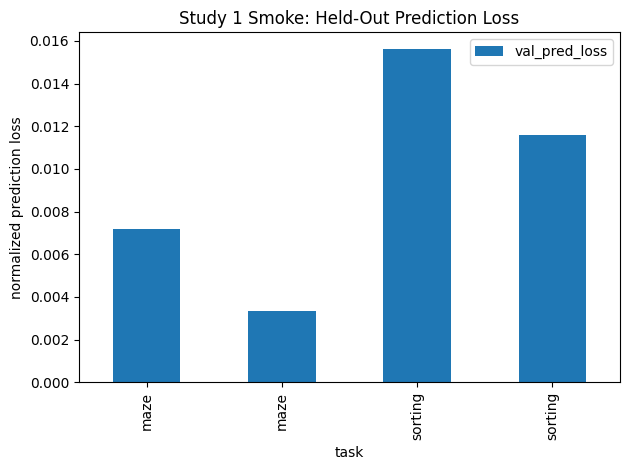

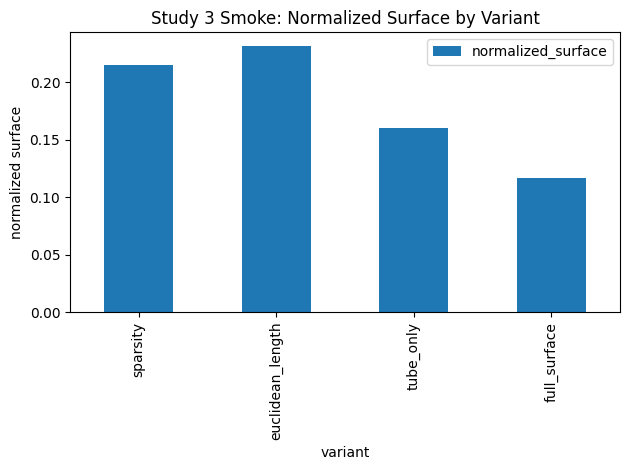

Figure directory: /content/grcshjepa/runs/colab_smoke/figures


In [9]:
# ============================================================
# 9. Lightweight plots for smoke diagnostics
# ============================================================
# These plots are exploratory pipeline checks only.
import matplotlib.pyplot as plt

fig_dir = SMOKE_OUTPUT_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

study1_files = sorted(SMOKE_OUTPUT_DIR.rglob("study1_seed*.csv"))
if study1_files:
    df1 = pd.read_csv(study1_files[0])
    ax = df1.plot.bar(x="task", y="val_pred_loss", title="Study 1 Smoke: Held-Out Prediction Loss")
    ax.set_ylabel("normalized prediction loss")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(fig_dir / "study1_prediction_loss_smoke.png", dpi=160)
    plt.show()

study3_files = sorted(SMOKE_OUTPUT_DIR.rglob("study3_seed*.csv"))
if study3_files:
    df3 = pd.read_csv(study3_files[0])
    base = df3[df3["damage_type"] == "none"]
    ax = base.plot.bar(x="variant", y="normalized_surface", title="Study 3 Smoke: Normalized Surface by Variant")
    ax.set_ylabel("normalized surface")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(fig_dir / "study3_normalized_surface_smoke.png", dpi=160)
    plt.show()

print("Figure directory:", fig_dir)


In [10]:
# ============================================================
# 10. Archive outputs to Google Drive when available
# ============================================================
from grcshjepa.utils import archive_directory

timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
archive_path = PROJECT_DIR / "runs" / f"colab_smoke_{timestamp}.tar.gz"
archive_directory(SMOKE_OUTPUT_DIR, archive_path)
print("Local archive:", archive_path)

if DRIVE_ARTIFACT_DIR.exists():
    DRIVE_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    target = DRIVE_ARTIFACT_DIR / archive_path.name
    shutil.copy2(archive_path, target)
    print("Copied archive to Drive:", target)
else:
    print("Drive artifact directory not available; archive remains local.")


Local archive: /content/grcshjepa/runs/colab_smoke_20260726T154914Z.tar.gz
Copied archive to Drive: /content/drive/MyDrive/grcshjepa_artifacts/colab_smoke_20260726T154914Z.tar.gz


## Optional: Run multiple seeds

The cell below is disabled by default. Only enable it after the tests and smoke run pass. For dissertation confirmatory runs, freeze configurations, sample size, analysis code, and seed lists before launching the runs.


In [11]:
# ============================================================
# 11. Optional multi-seed run loop -- disabled by default
# ============================================================
RUN_MULTI_SEED = True
SEEDS = list(range(4))  # expand only after smoke tests and protocol freeze

if RUN_MULTI_SEED:
    for seed in SEEDS:
        out = PROJECT_DIR / "runs" / f"pilot_seed_{seed:03d}"
        out.mkdir(parents=True, exist_ok=True)
        run(
            [
                sys.executable,
                "scripts/run_all_smoke.py",
                "--config",
                "configs/smoke.yaml",
                "--seed",
                str(seed),
                "--output-dir",
                str(out),
                "--archive",
            ],
            cwd=PROJECT_DIR,
            check=True,
            env=os.environ.copy(),
        )
    print("Completed multi-seed pilot loop.")
else:
    print("RUN_MULTI_SEED=False; skipping multi-seed loop.")


$ /usr/bin/python3 scripts/run_all_smoke.py --config configs/smoke.yaml --seed 0 --output-dir /content/grcshjepa/runs/pilot_seed_000 --archive
N              NaN                 NaN                NaN         NaN        NaN        NaN       NaN        NaN       NaN       NaN            NaN        tube_only       uniform          0.05      72.0             65.0     26.153865   6.676863       0.973566  7.650429          47.379926            0.161470      0.566161   0.577396             0.001568             4.258786
study3          NaN       NaN   NaN      NaN        NaN            NaN           NaN           NaN             NaN             NaN                NaN            NaN            NaN              NaN              NaN                 NaN                NaN         NaN        NaN        NaN       NaN        NaN       NaN       NaN            NaN        tube_only       uniform          0.10      72.0             62.0     25.689792   6.752275       0.996329  7.748604          49.5875

## Optional: Commit the scaffold to GitHub

After creating a GitHub repository, set `REPO_URL` in the first cell, or initialize Git manually in the cell below. Do not paste private access tokens directly into notebook cells. Use Colab secrets or the GitHub UI.


In [12]:
# ============================================================
# 12. Optional Git commands -- disabled by default
# ============================================================
RUN_GIT_COMMIT = False

if RUN_GIT_COMMIT:
    run(["git", "status"], cwd=PROJECT_DIR, check=False)
    run(["git", "add", "pyproject.toml", "README.md", "configs", "src", "tests", "scripts"], cwd=PROJECT_DIR, check=True)
    run(["git", "commit", "-m", "Bootstrap GR-CS-HJEPA Chapter 4 Colab pipeline"], cwd=PROJECT_DIR, check=False)
    # Uncomment only after setting up authentication safely.
    # run(["git", "push"], cwd=PROJECT_DIR, check=True)
else:
    print("RUN_GIT_COMMIT=False; skipping Git commit.")


RUN_GIT_COMMIT=False; skipping Git commit.
